# 02 - Baseline Modelling Lokal YOLOv8n

Notebook ini menjalankan baseline YOLOv8n untuk dataset N-RDD2024 subset Asia 6 kelas di lokal. Alurnya dibuat untuk kebutuhan TA: audit dataset, training baseline, evaluasi validasi/test, analisis per kelas, speed/FPS, prediksi sampel, dan template evaluasi zero-shot untuk data primer Bandung.

Keputusan imbalance di notebook ini: run baseline utama memakai loss bawaan YOLOv8n terlebih dahulu. Focal loss tidak dijadikan baseline utama karena baseline harus menjadi pembanding bersih terhadap eksperimen berikutnya. Focal loss disiapkan sebagai ablation opsional setelah metrik per kelas menunjukkan kelas minoritas seperti `Pothole` atau `patchy_road` memang tertinggal signifikan.

## Kebutuhan Lokal

Direkomendasikan:

- Python 3.10 sampai 3.12.
- GPU NVIDIA dengan CUDA untuk training 300 epoch. CPU bisa jalan, tetapi sangat lambat.
- Package pada `code/requirements_yolov8_local.txt`.
- Dataset sudah berada di `data/NRDD-2024/RDD_Split_Final_china_japan_india_6_classes/RDD_Split_Final_china_japan_india_6_classes/`.

Jika menggunakan GPU NVIDIA dan PyTorch yang terpasang masih CPU-only, pasang PyTorch CUDA dari instruksi resmi PyTorch terlebih dahulu, lalu install requirements notebook ini.

In [ ]:
# Jalankan sekali jika environment belum lengkap.
# Setelah install selesai, restart kernel notebook agar import library bersih.
from pathlib import Path

requirements_file = Path("requirements_yolov8_local.txt")
if not requirements_file.exists():
    requirements_file = Path("code/requirements_yolov8_local.txt")

%pip install -U -r {requirements_file}

In [2]:
from pathlib import Path
from collections import Counter
import json
import os
import random
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from IPython.display import Image, display
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Notebook bisa dibuka dari root repo atau dari folder code.
ROOT_CANDIDATES = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path("D:/01_Akademik/TA-Project"),
]
REPO_ROOT = next((p for p in ROOT_CANDIDATES if (p / "proposal.pdf").exists() and (p / "data").exists()), Path.cwd().resolve())

DATASET_DIR = REPO_ROOT / "data/NRDD-2024/RDD_Split_Final_china_japan_india_6_classes/RDD_Split_Final_china_japan_india_6_classes"
OUTPUT_DIR = REPO_ROOT / "runs/rdd_yolov8n_local"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [
    "Longitudinal_Crack",
    "Transverse_Crack",
    "Alligator_Crack",
    "Pothole",
    "manhole",
    "patchy_road",
]

print(f"Repo root   : {REPO_ROOT}")
print(f"Dataset dir : {DATASET_DIR}")
print(f"Output dir  : {OUTPUT_DIR}")
assert DATASET_DIR.exists(), f"Dataset tidak ditemukan: {DATASET_DIR}"

Repo root   : D:\01_Akademik\TA-Project
Dataset dir : D:\01_Akademik\TA-Project\data\NRDD-2024\RDD_Split_Final_china_japan_india_6_classes\RDD_Split_Final_china_japan_india_6_classes
Output dir  : D:\01_Akademik\TA-Project\runs\rdd_yolov8n_local


In [3]:
print(f"Torch version       : {torch.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device count   : {torch.cuda.device_count()}")
    print(f"Current GPU         : {torch.cuda.get_device_name(0)}")
    DEVICE = 0
    BATCH = 32
else:
    print("Training akan berjalan di CPU. Untuk 300 epoch, sangat disarankan memakai GPU.")
    DEVICE = "cpu"
    BATCH = 4

# Windows notebook lebih stabil dengan workers=0.
WORKERS = 0 if os.name == "nt" else 4
print(f"Device untuk YOLO   : {DEVICE}")
print(f"Batch awal          : {BATCH}")
print(f"Dataloader workers  : {WORKERS}")

Torch version       : 2.6.0+cu124
CUDA available      : True
CUDA device count   : 1
Current GPU         : NVIDIA GeForce RTX 3050 6GB Laptop GPU
Device untuk YOLO   : 0
Batch awal          : 32
Dataloader workers  : 0


## Siapkan YAML Lokal

File YAML bawaan dataset memakai `path: .`. Untuk mencegah error saat notebook dijalankan dari folder berbeda, cell berikut membuat YAML turunan dengan path absolut dan nama kelas yang konsisten dengan statistik penelitian.

In [4]:
original_yaml = DATASET_DIR / "data.yaml"
with original_yaml.open("r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

data_cfg["path"] = str(DATASET_DIR.resolve()).replace("\\", "/")
data_cfg["train"] = "train/images"
data_cfg["val"] = "val/images"
data_cfg["test"] = "test/images"
data_cfg["nc"] = len(CLASS_NAMES)
data_cfg["names"] = CLASS_NAMES

local_yaml = OUTPUT_DIR / "rdd6_local.yaml"
with local_yaml.open("w", encoding="utf-8") as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False, allow_unicode=False)

print(local_yaml)
print(local_yaml.read_text(encoding="utf-8"))

D:\01_Akademik\TA-Project\runs\rdd_yolov8n_local\rdd6_local.yaml
path: D:/01_Akademik/TA-Project/data/NRDD-2024/RDD_Split_Final_china_japan_india_6_classes/RDD_Split_Final_china_japan_india_6_classes
train: train/images
val: val/images
test: test/images
nc: 6
names:
- Longitudinal_Crack
- Transverse_Crack
- Alligator_Crack
- Pothole
- manhole
- patchy_road



## Audit Dataset

Audit ini memastikan jumlah gambar, label, objek, missing label, dan extra label aman sebelum training. File `classes.txt` di folder labels diabaikan karena bukan anotasi gambar.

In [5]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def list_images(split: str):
    image_dir = DATASET_DIR / split / "images"
    return sorted([p for p in image_dir.iterdir() if p.suffix.lower() in IMG_EXTS])


def list_label_files(split: str):
    label_dir = DATASET_DIR / split / "labels"
    return sorted([p for p in label_dir.glob("*.txt") if p.name.lower() != "classes.txt"])


def read_yolo_labels(label_path: Path):
    rows = []
    for line_no, line in enumerate(label_path.read_text(encoding="utf-8", errors="ignore").splitlines(), start=1):
        parts = line.strip().split()
        if not parts:
            continue
        if len(parts) != 5:
            rows.append({"file": label_path.name, "line": line_no, "error": "not_5_columns", "raw": line})
            continue
        cls, x, y, w, h = parts
        try:
            rows.append({
                "file": label_path.name,
                "class_id": int(float(cls)),
                "x": float(x),
                "y": float(y),
                "w": float(w),
                "h": float(h),
            })
        except ValueError:
            rows.append({"file": label_path.name, "line": line_no, "error": "parse_error", "raw": line})
    return rows

summary_rows = []
label_rows = []
invalid_rows = []

for split in ["train", "val", "test"]:
    images = list_images(split)
    labels = list_label_files(split)
    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}

    split_counter = Counter()
    split_objects = 0
    for label_path in labels:
        for row in read_yolo_labels(label_path):
            if "error" in row:
                invalid_rows.append({"split": split, **row})
                continue
            class_id = row["class_id"]
            if class_id < 0 or class_id >= len(CLASS_NAMES):
                invalid_rows.append({"split": split, "file": row["file"], "error": "class_id_out_of_range", "class_id": class_id})
                continue
            if not all(0.0 <= row[k] <= 1.0 for k in ["x", "y", "w", "h"]):
                invalid_rows.append({"split": split, "file": row["file"], "error": "bbox_out_of_0_1_range", **row})
                continue
            split_counter[class_id] += 1
            split_objects += 1
            label_rows.append({"split": split, "class_id": class_id, "class_name": CLASS_NAMES[class_id], **row})

    summary_rows.append({
        "split": split,
        "images": len(images),
        "labels": len(labels),
        "objects": split_objects,
        "missing_label_files": len(image_stems - label_stems),
        "extra_label_files": len(label_stems - image_stems),
    })

summary_df = pd.DataFrame(summary_rows)
labels_df = pd.DataFrame(label_rows)
invalid_df = pd.DataFrame(invalid_rows)

class_df = (
    labels_df.groupby(["split", "class_id", "class_name"])
    .size()
    .rename("objects")
    .reset_index()
)
class_pivot = class_df.pivot_table(index=["class_id", "class_name"], columns="split", values="objects", fill_value=0).reset_index()
for col in ["train", "val", "test"]:
    if col not in class_pivot.columns:
        class_pivot[col] = 0
class_pivot["total"] = class_pivot[["train", "val", "test"]].sum(axis=1)
class_pivot["percent"] = class_pivot["total"] / class_pivot["total"].sum() * 100

print("Summary split:")
display(summary_df)
print("Distribusi kelas:")
display(class_pivot[["class_id", "class_name", "train", "val", "test", "total", "percent"]])

assert invalid_df.empty, f"Ada label invalid, cek invalid_df: {invalid_df.head()}"
assert (summary_df["missing_label_files"] == 0).all(), "Ada gambar tanpa label."
assert (summary_df["extra_label_files"] == 0).all(), "Ada label tanpa gambar."

class_pivot.to_csv(OUTPUT_DIR / "dataset_class_distribution.csv", index=False)
summary_df.to_csv(OUTPUT_DIR / "dataset_split_summary.csv", index=False)

Summary split:


,split,images,labels,objects,missing_label_files,extra_label_files
0,train,6777,6777,17092,0,0
1,val,1898,1898,4773,0,0
2,test,995,995,2425,0,0


Distribusi kelas:


split,class_id,class_name,train,val,test,total,percent
0,0,Longitudinal_Crack,4555.0,1257.0,635.0,6447.0,26.541787
1,1,Transverse_Crack,3219.0,897.0,446.0,4562.0,18.781392
2,2,Alligator_Crack,4385.0,1245.0,642.0,6272.0,25.821326
3,3,Pothole,2192.0,597.0,312.0,3101.0,12.766571
4,4,manhole,2270.0,645.0,321.0,3236.0,13.322355
5,5,patchy_road,471.0,132.0,69.0,672.0,2.766571


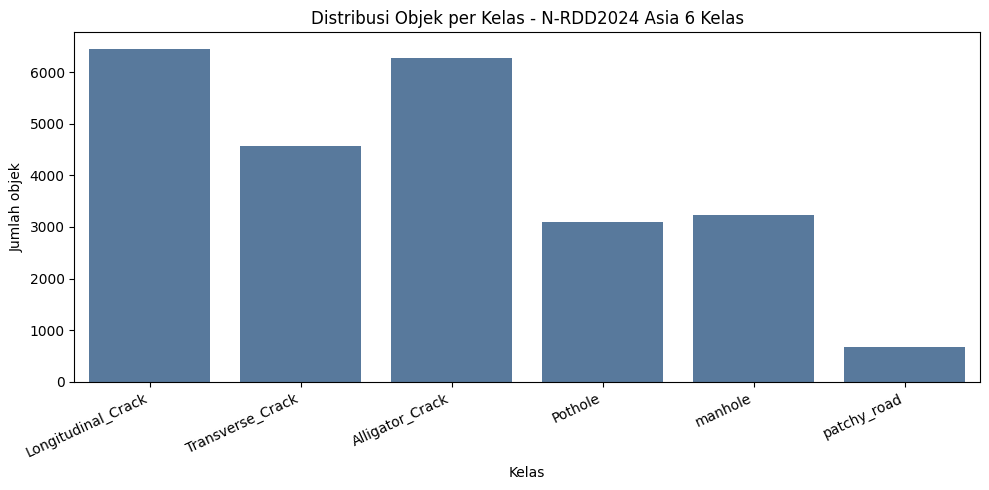

Imbalance ratio mayoritas:minimal = 9.59x


In [6]:
plt.figure(figsize=(10, 5))
sns.barplot(data=class_pivot, x="class_name", y="total", color="#4C78A8")
plt.xticks(rotation=25, ha="right")
plt.title("Distribusi Objek per Kelas - N-RDD2024 Asia 6 Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah objek")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution.png", dpi=160)
plt.show()

imbalance_ratio = class_pivot["total"].max() / class_pivot["total"].min()
print(f"Imbalance ratio mayoritas:minimal = {imbalance_ratio:.2f}x")

## Visualisasi Sampel Label

Cek cepat apakah bounding box dan class ID sudah benar. Jika gambar tampak salah, jangan lanjut training sebelum format label dibetulkan.

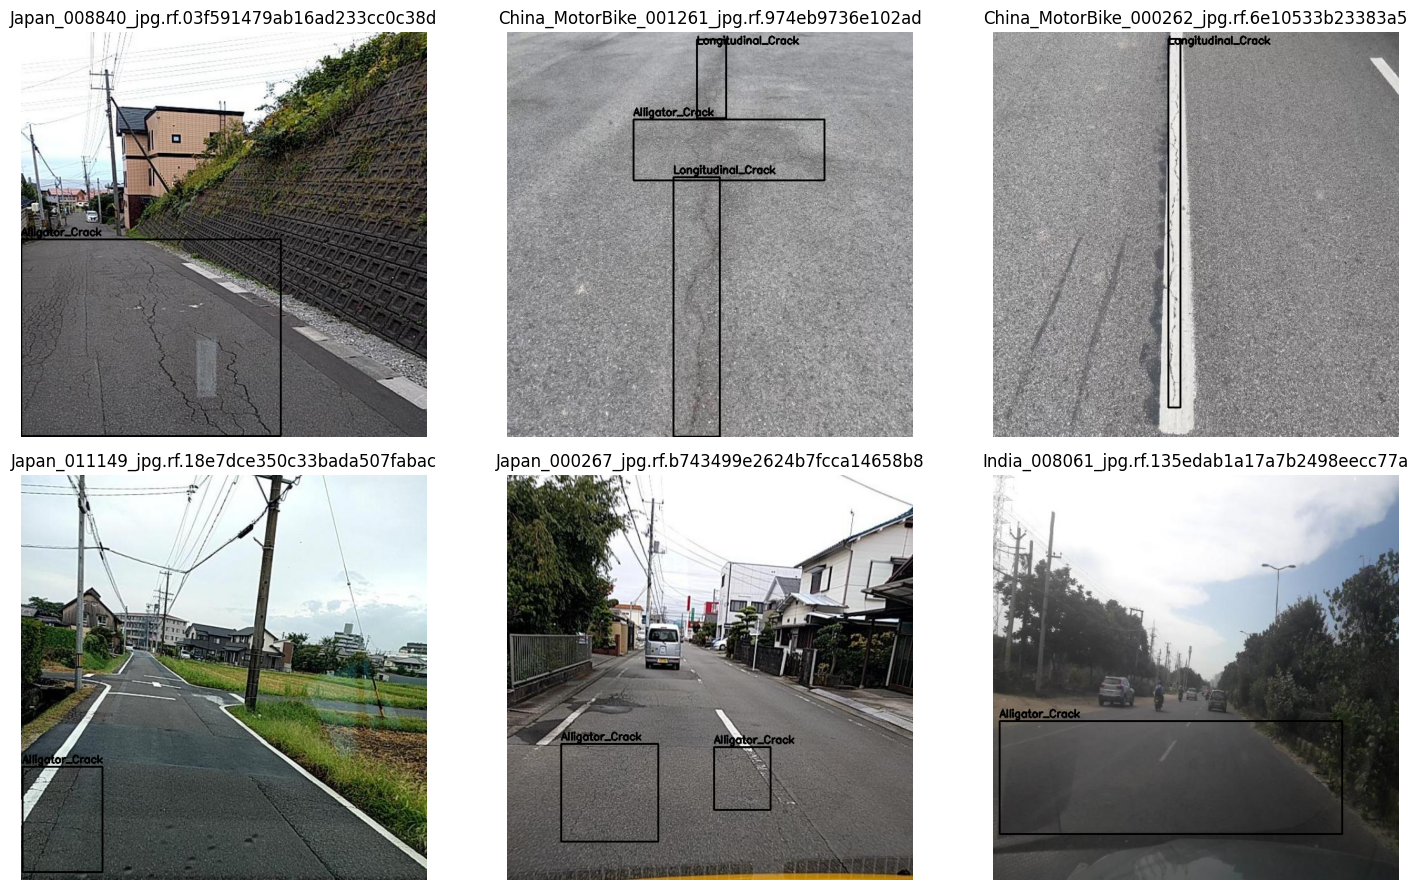

In [7]:
def draw_yolo_boxes(image_path: Path, label_path: Path):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise ValueError(f"Gagal membaca gambar: {image_path}")
    image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    h_img, w_img = image.shape[:2]

    for row in read_yolo_labels(label_path):
        if "error" in row:
            continue
        cls = int(row["class_id"])
        x, y, w, h = row["x"], row["y"], row["w"], row["h"]
        x1 = int((x - w / 2) * w_img)
        y1 = int((y - h / 2) * h_img)
        x2 = int((x + w / 2) * w_img)
        y2 = int((y + h / 2) * h_img)
        color = tuple(int(c) for c in sns.color_palette("tab10", len(CLASS_NAMES))[cls])
        color = tuple(int(c * 255) for c in color)
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(image, CLASS_NAMES[cls], (x1, max(20, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
    return image

sample_images = random.sample(list_images("train"), k=min(6, len(list_images("train"))))
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for ax, image_path in zip(axes, sample_images):
    label_path = DATASET_DIR / "train/labels" / f"{image_path.stem}.txt"
    ax.imshow(draw_yolo_boxes(image_path, label_path))
    ax.set_title(image_path.name[:45])
    ax.axis("off")
for ax in axes[len(sample_images):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Training Baseline YOLOv8n

Baseline dibuat sebagai pembanding bersih: `yolov8n.pt`, input 640, native Ultralytics detection loss, Mosaic aktif, seed tetap, dan output tersimpan di `runs/rdd_yolov8n_local/experiments/`.

Untuk laptop/PC lokal, mulai dari `BATCH=8` atau `16`. Jika GPU out-of-memory, turunkan batch. Untuk eksperimen final sesuai proposal, gunakan `EPOCHS=300`.

In [ ]:
RUN_TRAINING = True
SMOKE_TEST = False

EPOCHS = 5 if SMOKE_TEST else 300
PATIENCE = 10 if SMOKE_TEST else 50
IMGSZ = 640
PROJECT_DIR = OUTPUT_DIR / "experiments"
RUN_NAME = "yolov8n_smoke_test" if SMOKE_TEST else "yolov8n_baseline_native_loss"


In [ ]:
RUN_TRAINING = True
SMOKE_TEST = False

EPOCHS = 5 if SMOKE_TEST else 300
PATIENCE = 10 if SMOKE_TEST else 50
IMGSZ = 640
PROJECT_DIR = OUTPUT_DIR / "experiments"
RUN_NAME = "yolov8n_smoke_test" if SMOKE_TEST else "yolov8n_baseline_native_loss"

if RUN_TRAINING:
    model = YOLO("yolov8n.pt")
    train_results = model.train(
        data=str(local_yaml),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        workers=WORKERS,
        project=str(PROJECT_DIR),
        name=RUN_NAME,
        exist_ok=True,
        seed=SEED,
        deterministic=True,
        pretrained=True,
        optimizer="auto",
        patience=PATIENCE,
        cache=False,
        amp=True,
        cos_lr=True,
        plots=True,
        save=True,
        save_period=25,
        close_mosaic=10,
        mosaic=1.0,
        mixup=0.05,
        fliplr=0.5,
        translate=0.10,
        scale=0.50,
        degrees=0.0,  # Tidak menggunakan rotasi sesuai arahan metodologi/dospem.
    )
else:
    print("RUN_TRAINING=False, training dilewati.")

In [ ]:
RUN_DIR = PROJECT_DIR / RUN_NAME
BEST_WEIGHTS = RUN_DIR / "weights/best.pt"
LAST_WEIGHTS = RUN_DIR / "weights/last.pt"

print(f"Run dir      : {RUN_DIR}")
print(f"Best weights : {BEST_WEIGHTS}")
print(f"Last weights : {LAST_WEIGHTS}")
assert BEST_WEIGHTS.exists(), "best.pt belum ada. Jalankan training terlebih dahulu atau ubah BEST_WEIGHTS ke path bobot yang sudah ada."

## Evaluasi Validasi dan Test

Validasi dipakai untuk monitoring selama training. Test set dipakai sebagai angka baseline final pada domain sumber. Ultralytics otomatis menyimpan confusion matrix, PR curve, F1 curve, dan hasil prediksi ke folder evaluasi.

In [11]:
best_model = YOLO(str(BEST_WEIGHTS))
EVAL_DIR = OUTPUT_DIR / "evaluation"

val_metrics = best_model.val(
    data=str(local_yaml),
    split="val",
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    workers=WORKERS,
    project=str(EVAL_DIR),
    name="val_baseline",
    exist_ok=True,
    plots=True,
    save_json=True,
    conf=0.001,
    iou=0.60,
)

test_metrics = best_model.val(
    data=str(local_yaml),
    split="test",
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    workers=WORKERS,
    project=str(EVAL_DIR),
    name="test_baseline",
    exist_ok=True,
    plots=True,
    save_json=True,
    conf=0.001,
    iou=0.60,
)

print("Validation metrics:")
print(val_metrics.results_dict)
print("Test metrics:")
print(test_metrics.results_dict)

Ultralytics 8.4.34  Python-3.12.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 372.4156.7 MB/s, size: 65.5 KB)
val: Scanning D:\01_Akademik\TA-Project\data\NRDD-2024\RDD_Split_Final_china_japan_india_6_classes\RDD_Split_Final_china_japan_india_6_classes\val\labels.cache... 1898 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1898/1898  0.0s
val: D:\01_Akademik\TA-Project\data\NRDD-2024\RDD_Split_Final_china_japan_india_6_classes\RDD_Split_Final_china_japan_india_6_classes\val\images\Japan_006916_jpg.rf.6409c53af3c26b4c760f816734ecafc8.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 60/60 2.5it/s 24.5s0.4ss
                   all       1898       4772      0.551      0.475      0.493       0.25
    Longitudinal_Crack        788       125

In [12]:
def per_class_metrics(metrics, class_names):
    rows = []
    box = metrics.box
    for class_id, class_name in enumerate(class_names):
        try:
            precision, recall, ap50, ap5095 = box.class_result(class_id)
        except Exception:
            precision, recall, ap50, ap5095 = np.nan, np.nan, np.nan, np.nan
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        rows.append({
            "class_id": class_id,
            "class_name": class_name,
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "mAP50": float(ap50),
            "mAP50-95": float(ap5095),
        })
    return pd.DataFrame(rows)

def safe_weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights)
    if not valid.any() or weights[valid].sum() == 0:
        return float("nan")
    return float(np.average(values[valid], weights=weights[valid]))

val_per_class = per_class_metrics(val_metrics, CLASS_NAMES)
test_per_class = per_class_metrics(test_metrics, CLASS_NAMES)

val_per_class = val_per_class.merge(
    class_pivot[["class_id", "val"]].rename(columns={"val": "support"}),
    on="class_id",
    how="left",
)
test_per_class = test_per_class.merge(
    class_pivot[["class_id", "test"]].rename(columns={"test": "support"}),
    on="class_id",
    how="left",
)

f1_summary = {
    "val_macro_f1": float(val_per_class["f1"].mean()),
    "val_weighted_f1": safe_weighted_mean(val_per_class["f1"], val_per_class["support"]),
    "test_macro_f1": float(test_per_class["f1"].mean()),
    "test_weighted_f1": safe_weighted_mean(test_per_class["f1"], test_per_class["support"]),
}
f1_summary_df = pd.DataFrame([f1_summary])

print("F1 summary:")
display(f1_summary_df)
print("Test per-class metrics:")
display(test_per_class)
val_per_class.to_csv(OUTPUT_DIR / "val_per_class_metrics.csv", index=False)
test_per_class.to_csv(OUTPUT_DIR / "test_per_class_metrics.csv", index=False)
f1_summary_df.to_csv(OUTPUT_DIR / "f1_summary.csv", index=False)

summary = {
    "weights": str(BEST_WEIGHTS),
    "data_yaml": str(local_yaml),
    "imgsz": IMGSZ,
    "batch": BATCH,
    "epochs": EPOCHS,
    "device": str(DEVICE),
    "val_results": {k: float(v) for k, v in val_metrics.results_dict.items()},
    "test_results": {k: float(v) for k, v in test_metrics.results_dict.items()},
    "f1_summary": f1_summary,
    "test_speed_ms_per_image": {k: float(v) for k, v in test_metrics.speed.items()},
}

speed_total_ms = sum(float(v) for k, v in test_metrics.speed.items() if k in ["preprocess", "inference", "postprocess"])
summary["test_fps_estimate"] = 1000.0 / speed_total_ms if speed_total_ms > 0 else None

with (OUTPUT_DIR / "baseline_summary.json").open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

F1 summary:


,val_macro_f1,val_weighted_f1,test_macro_f1,test_weighted_f1
0,0.500605,0.500994,0.495671,0.508936


Test per-class metrics:


,class_id,class_name,precision,recall,f1,mAP50,mAP50-95,support
0,0,Longitudinal_Crack,0.589720,0.439132,0.503406,0.477963,0.220978,635.0
1,1,Transverse_Crack,0.515967,0.280269,0.363233,0.347399,0.139901,446.0
2,2,Alligator_Crack,0.595210,0.554517,0.574144,0.593621,0.283751,642.0
3,3,Pothole,0.441419,0.403846,0.421797,0.360944,0.143878,312.0
4,4,manhole,0.618804,0.797508,0.696882,0.763308,0.406123,321.0
5,5,patchy_road,0.384829,0.449275,0.414563,0.431912,0.329916,69.0


{
  "weights": "D:\\01_Akademik\\TA-Project\\runs\\rdd_yolov8n_local\\experiments\\yolov8n_smoke_test\\weights\\best.pt",
  "data_yaml": "D:\\01_Akademik\\TA-Project\\runs\\rdd_yolov8n_local\\rdd6_local.yaml",
  "imgsz": 640,
  "batch": 32,
  "epochs": 5,
  "device": "0",
  "val_results": {
    "metrics/precision(B)": 0.5511963932467817,
    "metrics/recall(B)": 0.4747918059403308,
    "metrics/mAP50(B)": 0.493458841345459,
    "metrics/mAP50-95(B)": 0.25033200744285483,
    "fitness": 0.25033200744285483
  },
  "test_results": {
    "metrics/precision(B)": 0.5243251028477433,
    "metrics/recall(B)": 0.48742453477344894,
    "metrics/mAP50(B)": 0.4958578110388059,
    "metrics/mAP50-95(B)": 0.25409113768882075,
    "fitness": 0.25409113768882075
  },
  "f1_summary": {
    "val_macro_f1": 0.5006045974703136,
    "val_weighted_f1": 0.5009938632635399,
    "test_macro_f1": 0.49567073724349586,
    "test_weighted_f1": 0.508935839155108
  },
  "test_speed_ms_per_image": {
    "preprocess":

D:\01_Akademik\TA-Project\runs\rdd_yolov8n_local\evaluation\test_baseline\confusion_matrix.png


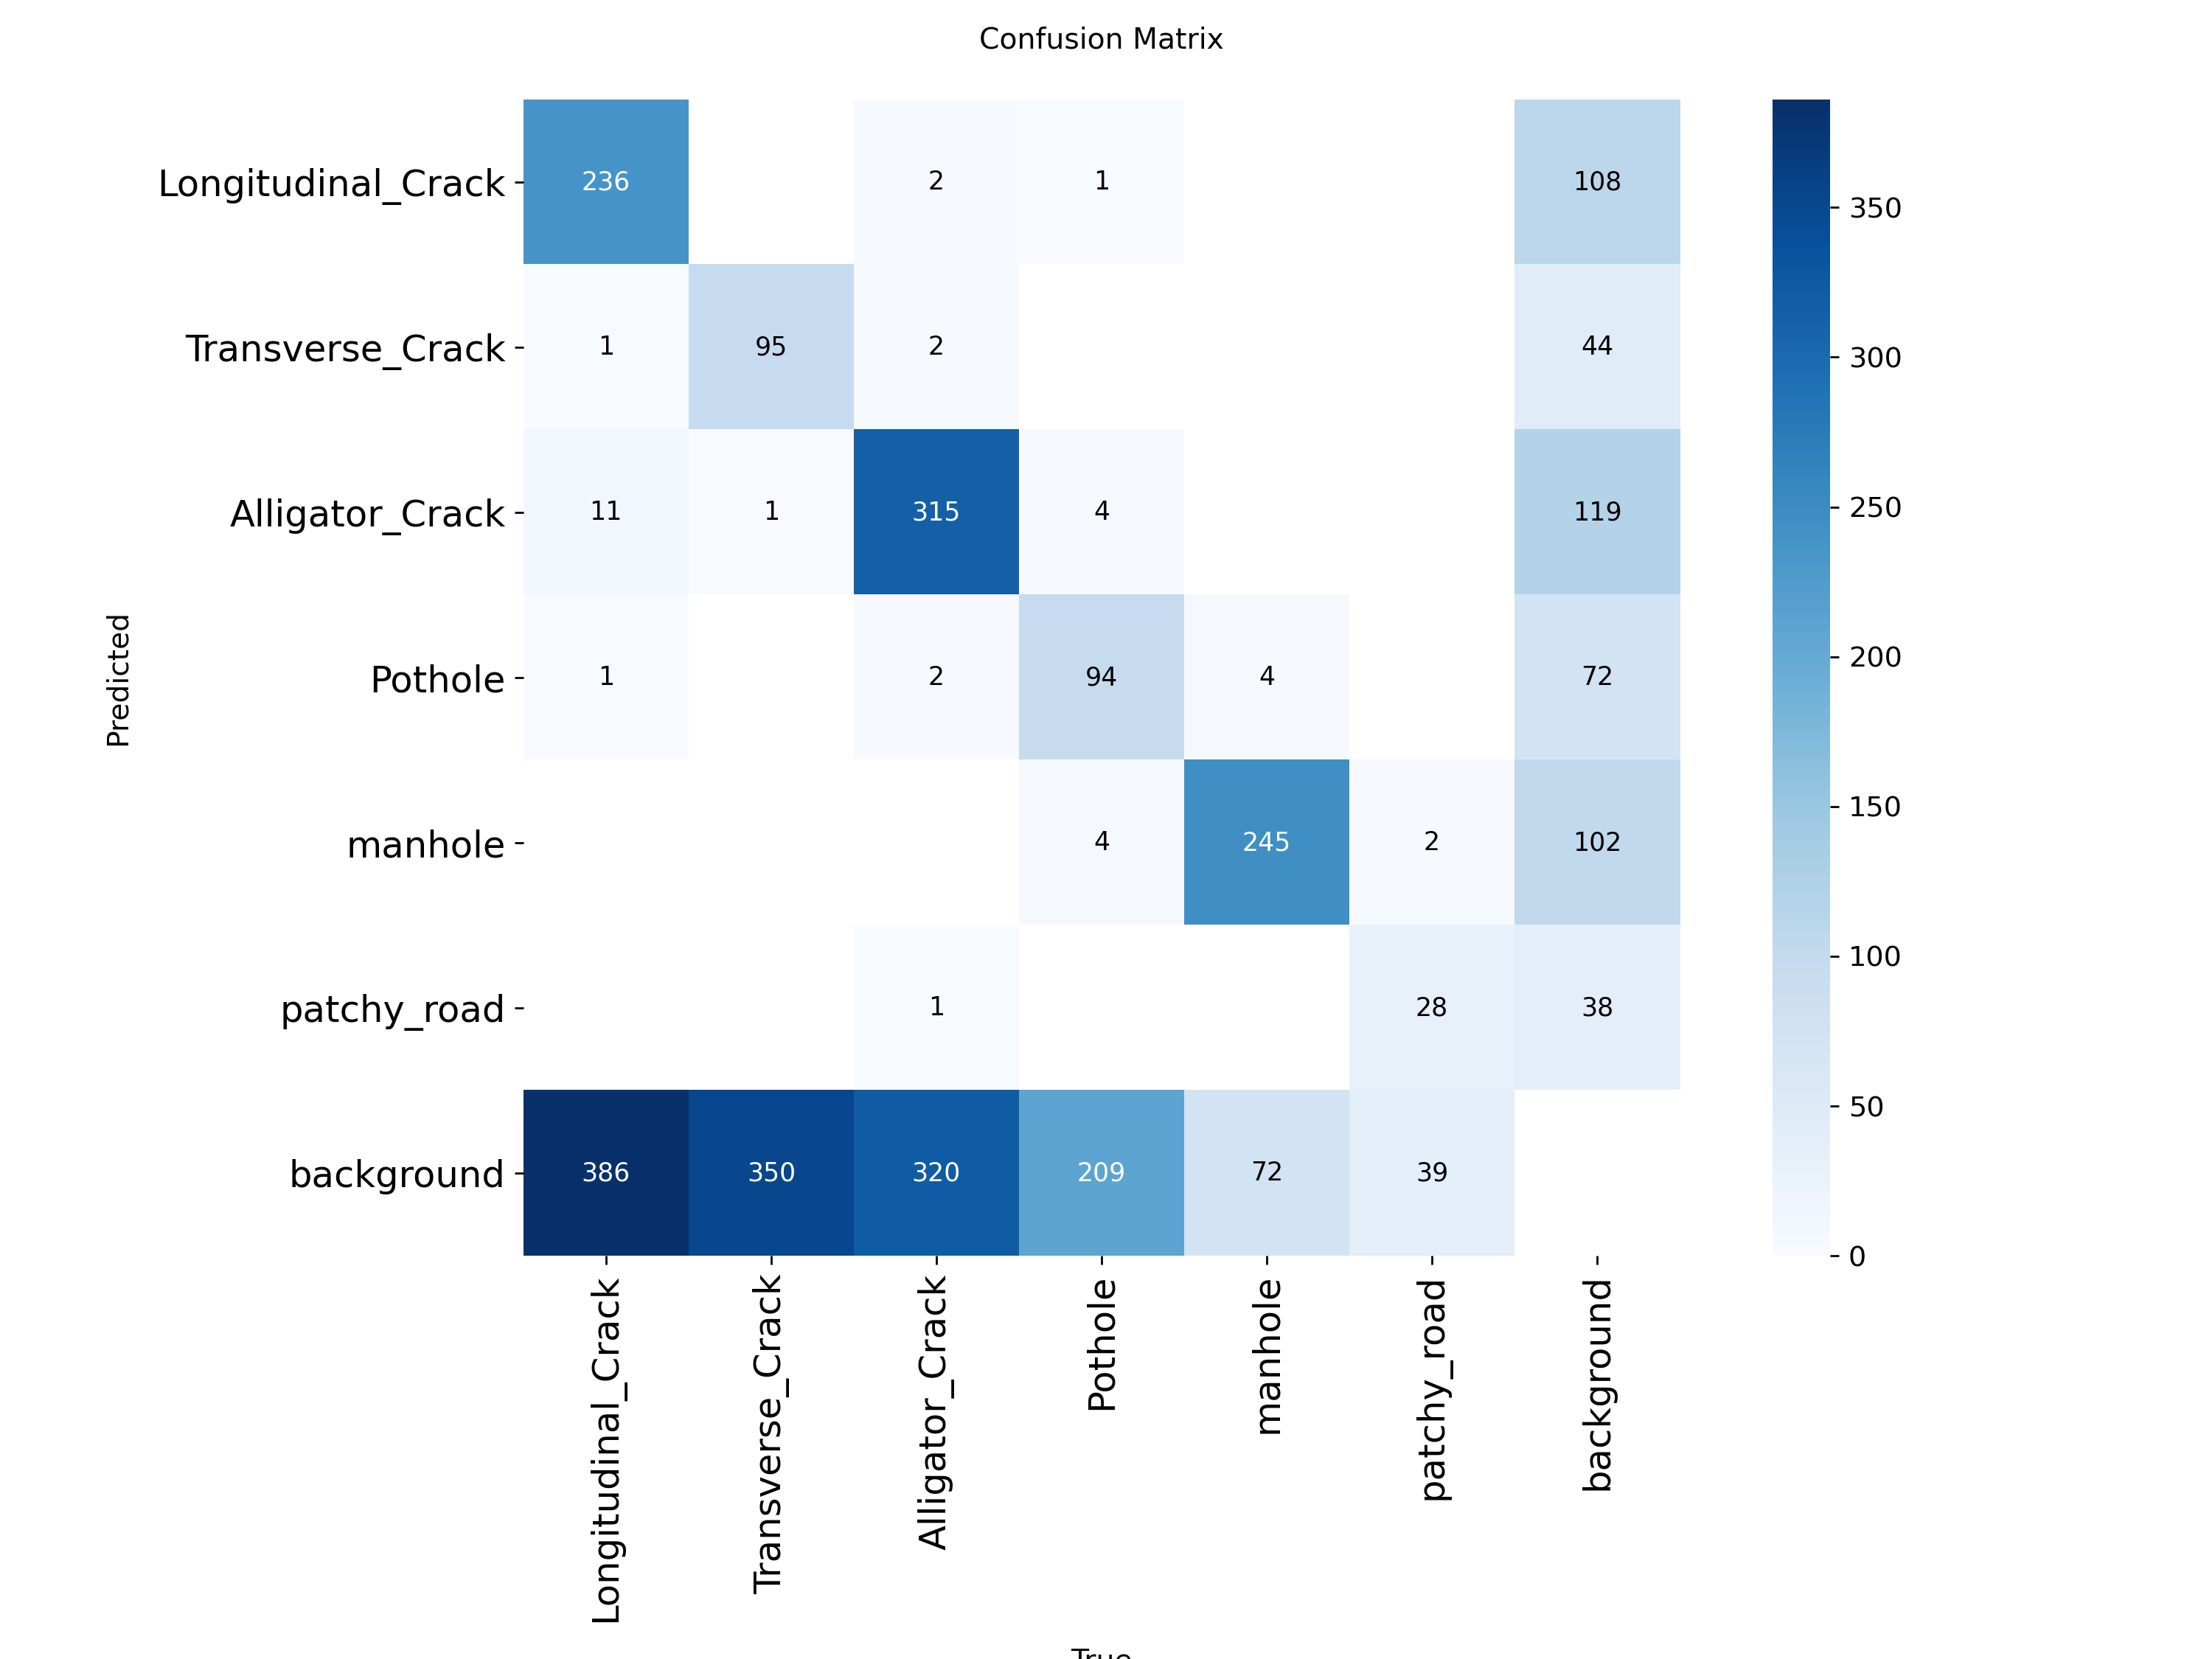

D:\01_Akademik\TA-Project\runs\rdd_yolov8n_local\evaluation\val_baseline\confusion_matrix.png


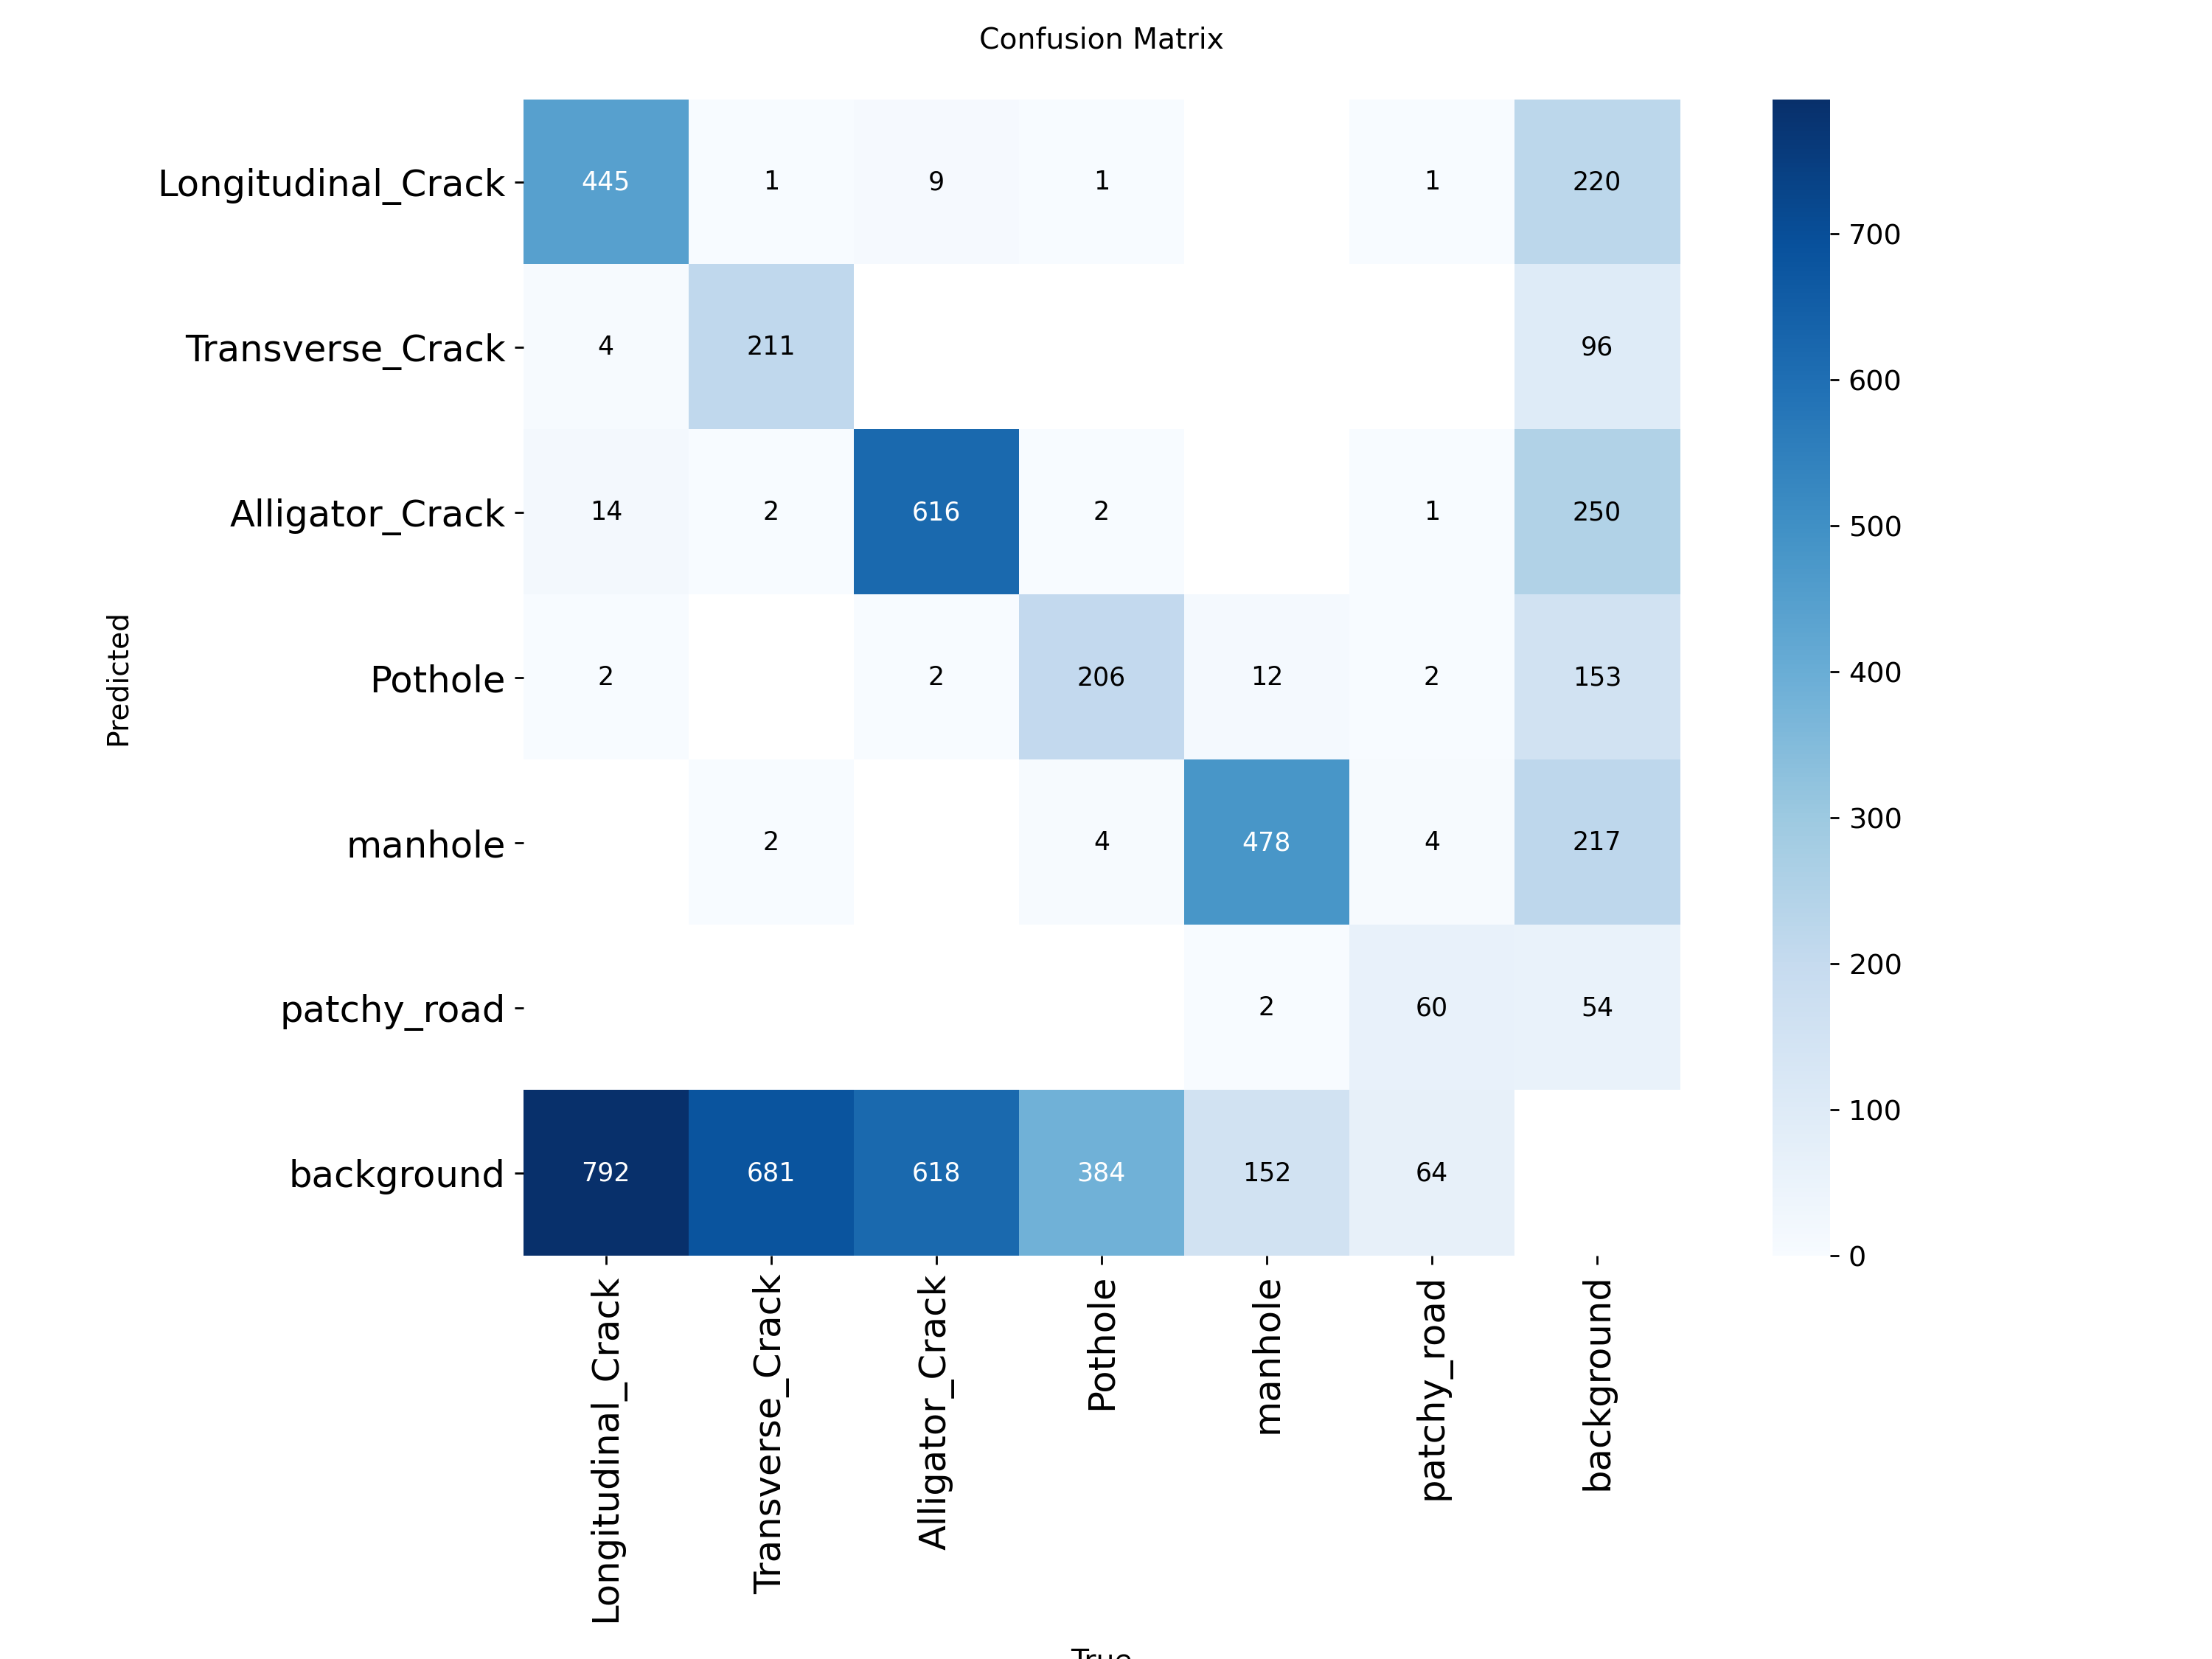

D:\01_Akademik\TA-Project\runs\rdd_yolov8n_local\evaluation\test_baseline\confusion_matrix_normalized.png


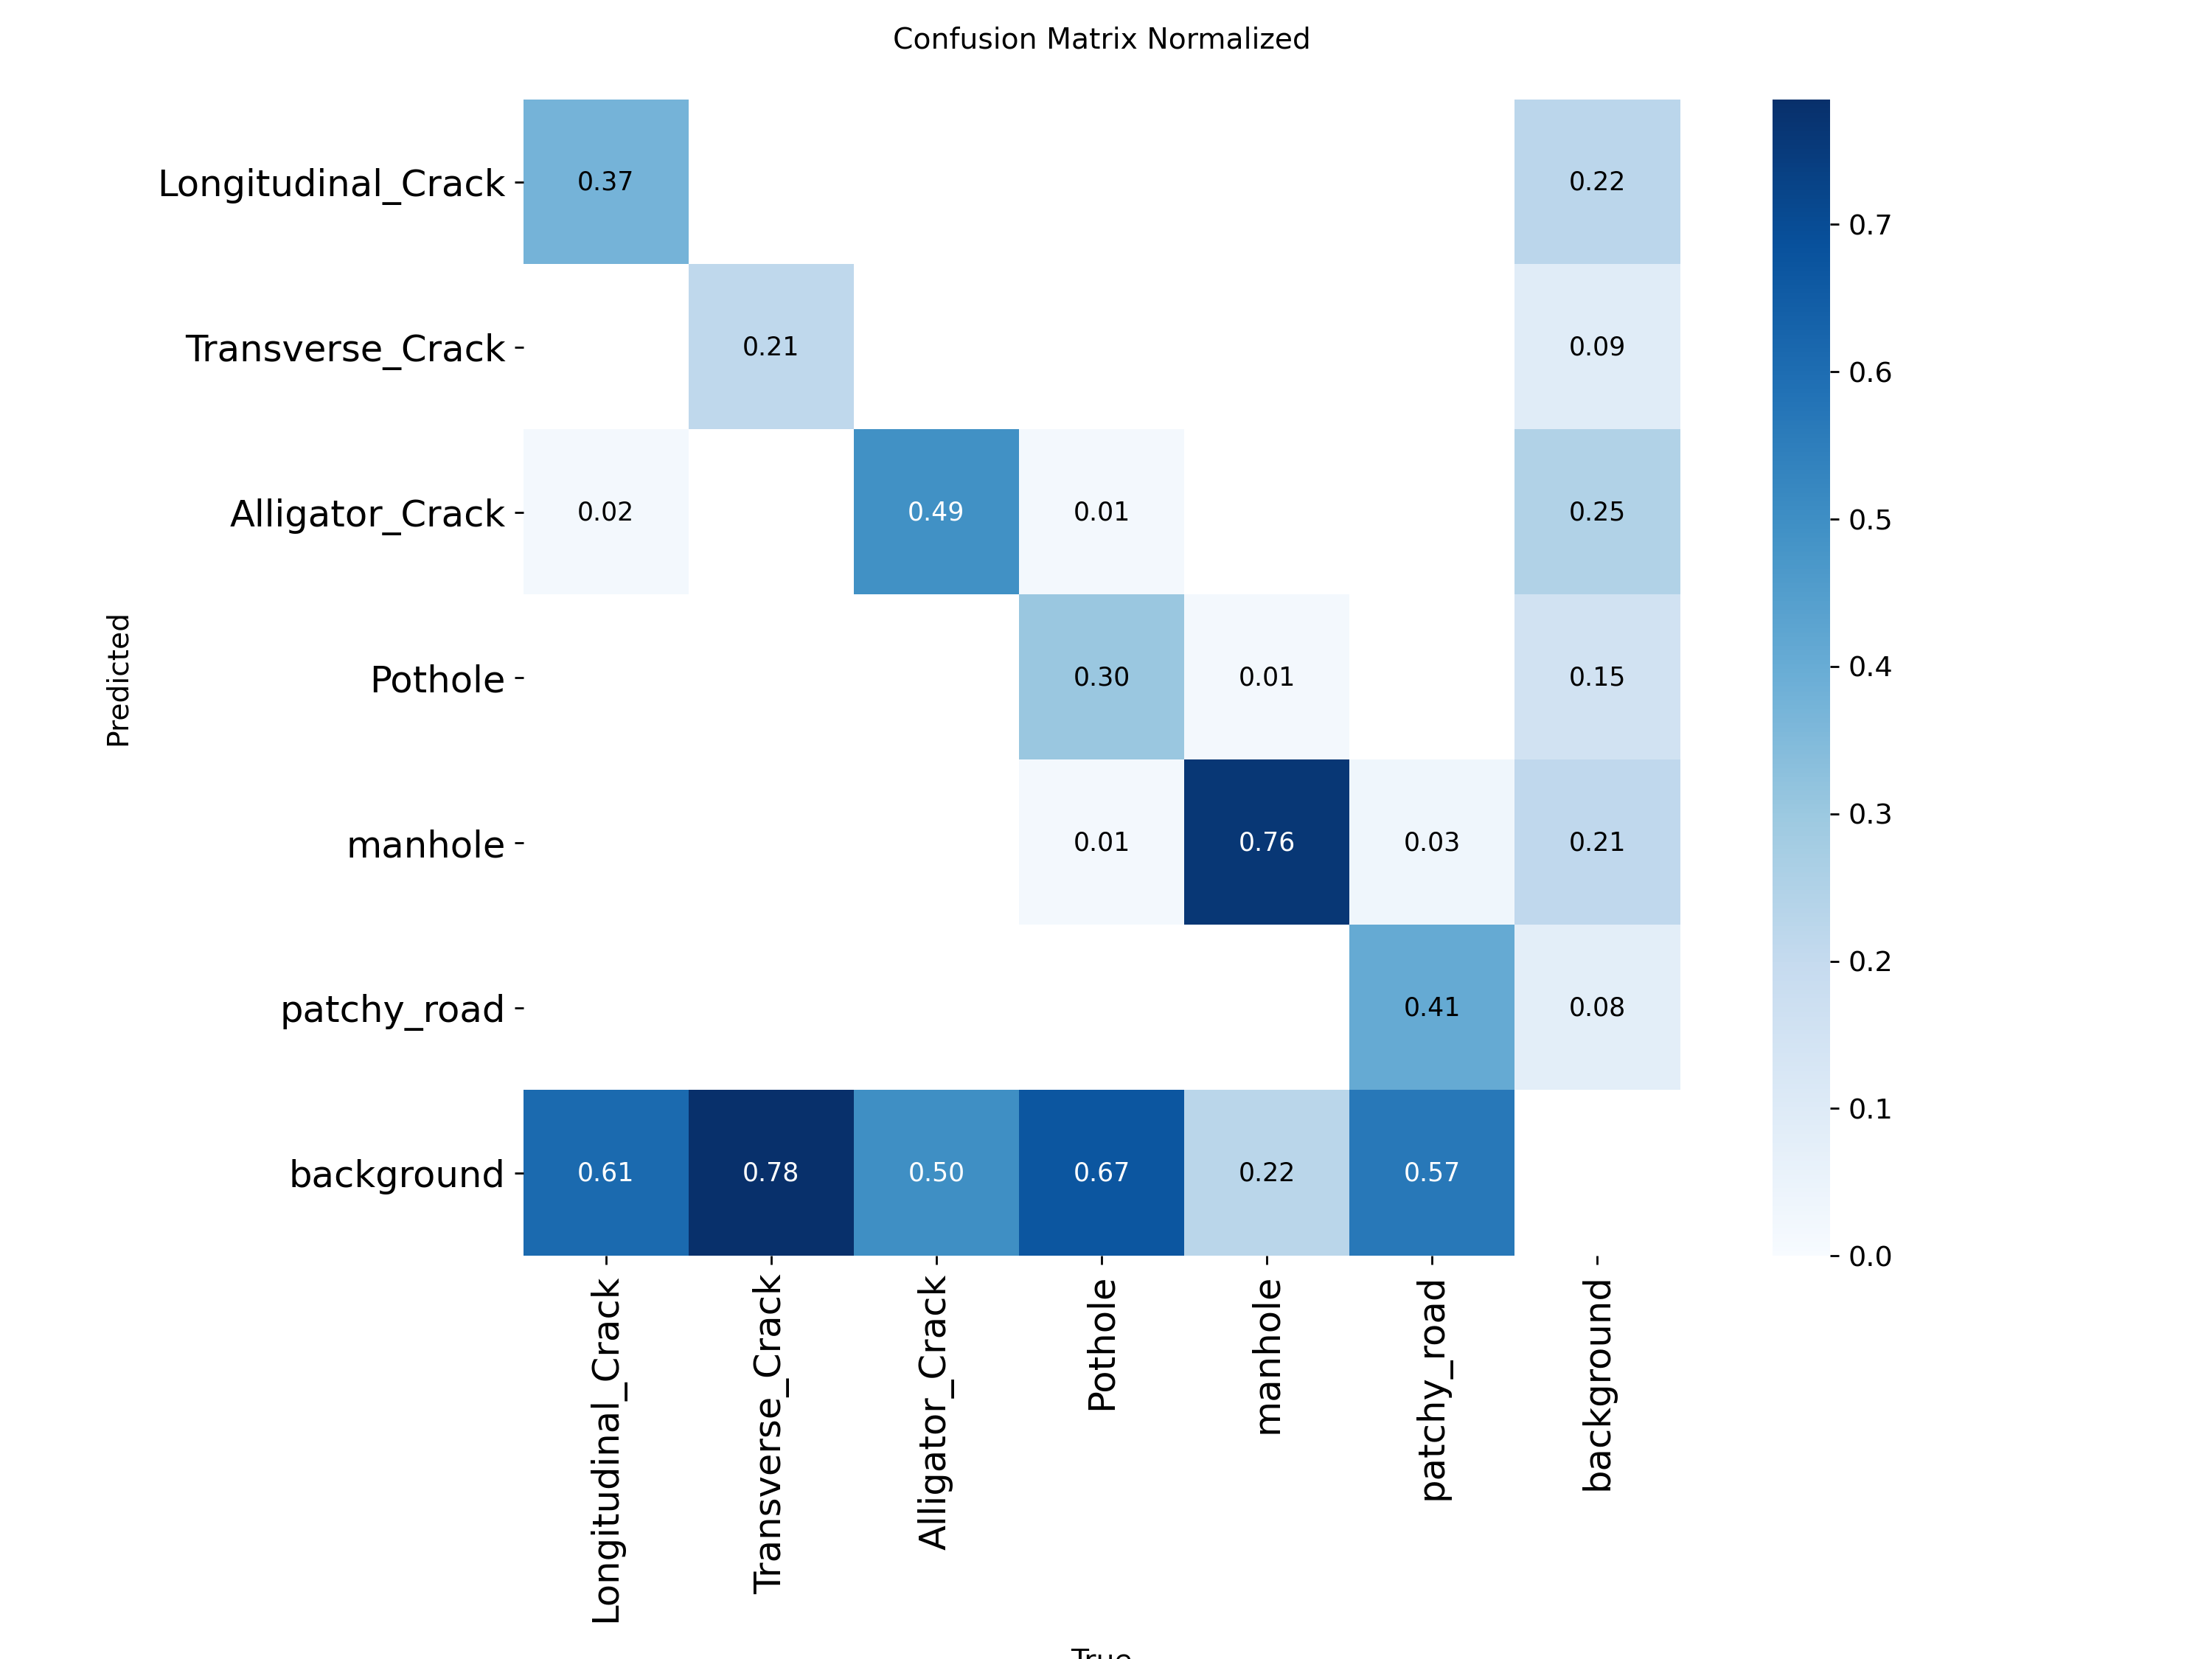

D:\01_Akademik\TA-Project\runs\rdd_yolov8n_local\evaluation\val_baseline\confusion_matrix_normalized.png


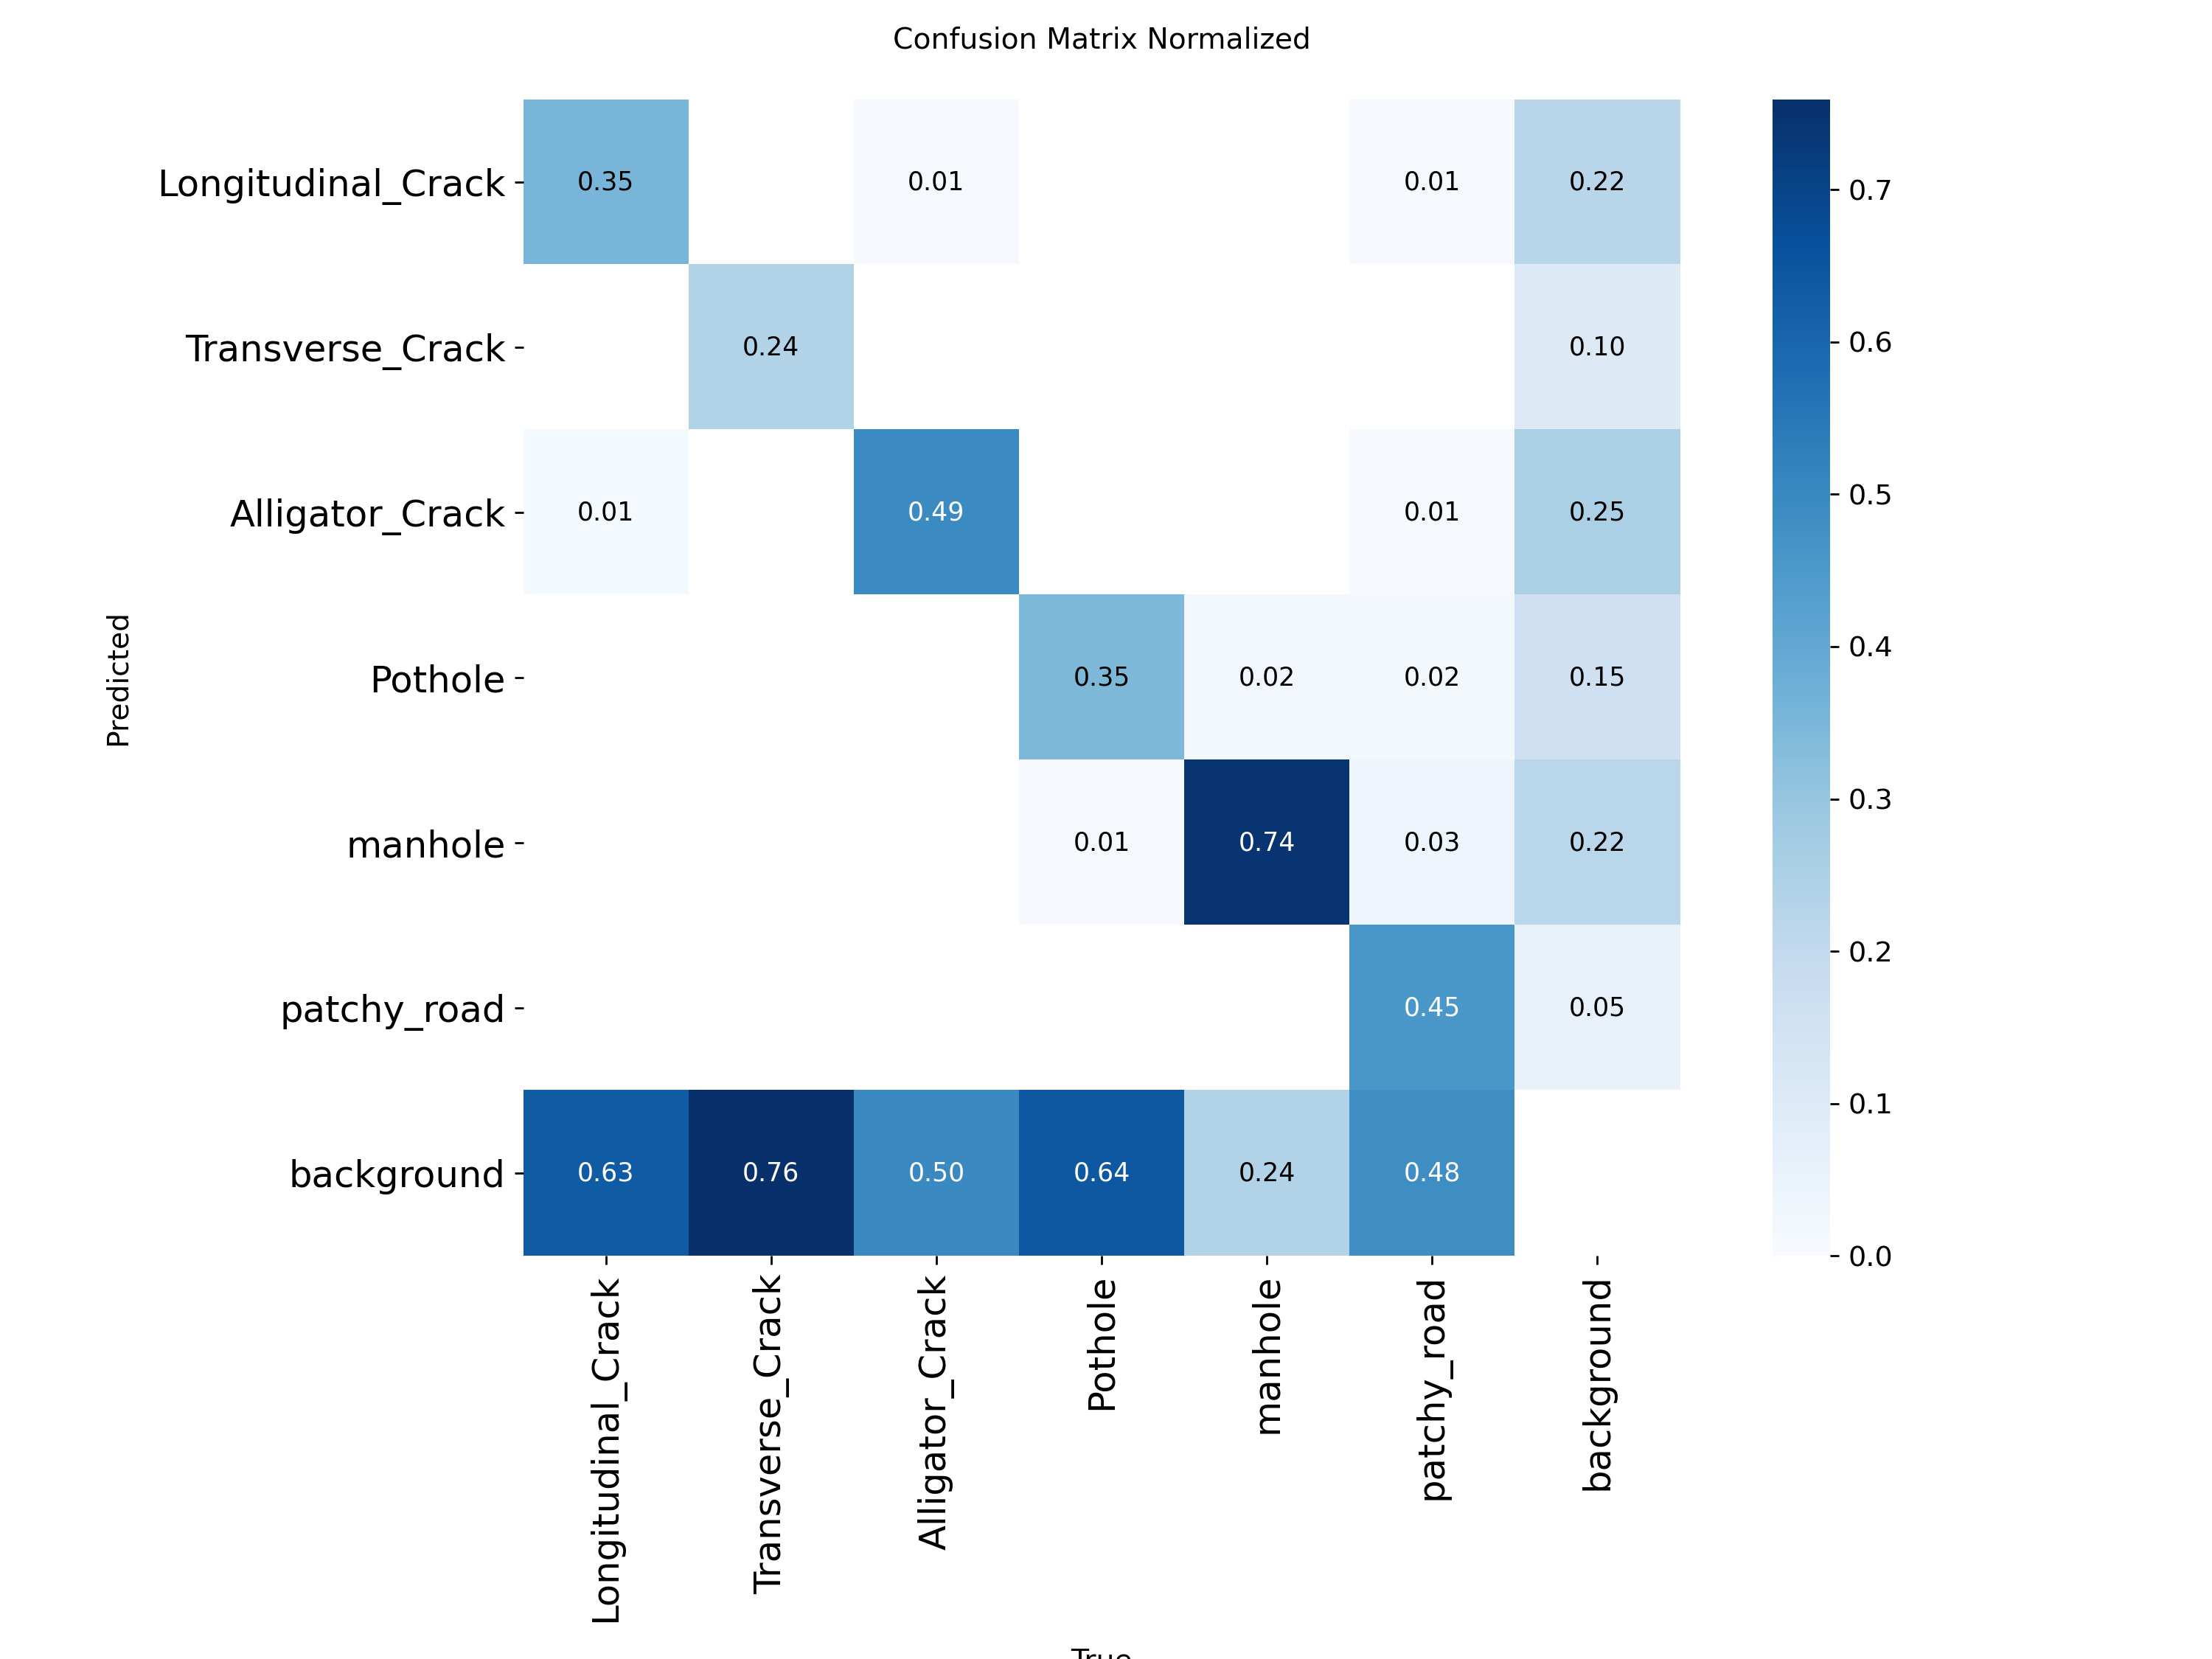

In [13]:
# Tampilkan artefak evaluasi yang paling penting jika tersedia.
for pattern in ["**/confusion_matrix.png", "**/confusion_matrix_normalized.png", "**/PR_curve.png", "**/F1_curve.png"]:
    for image_file in sorted(EVAL_DIR.glob(pattern)):
        print(image_file)
        display(Image(filename=str(image_file)))

## Prediksi Sampel Test

Cell ini membantu melihat false positive/false negative secara visual, terutama untuk pasangan yang mirip: `Pothole`, `manhole`, dan `patchy_road`.

In [14]:
PREDICT_DIR = OUTPUT_DIR / "predictions"
TEST_SAMPLE_COUNT = 24
CONF_THRES = 0.25
IOU_THRES = 0.60

test_images = list_images("test")
sample_test_images = random.sample(test_images, k=min(TEST_SAMPLE_COUNT, len(test_images)))

predict_results = best_model.predict(
    source=[str(p) for p in sample_test_images],
    imgsz=IMGSZ,
    conf=CONF_THRES,
    iou=IOU_THRES,
    device=DEVICE,
    project=str(PREDICT_DIR),
    name="test_samples_conf025",
    exist_ok=True,
    save=True,
    save_txt=True,
    save_conf=True,
)

print(f"Prediksi sampel tersimpan di: {PREDICT_DIR / 'test_samples_conf025'}")


0: 640x640 1 Longitudinal_Crack, 10.0ms
1: 640x640 1 Transverse_Crack, 2 manholes, 1 patchy_road, 10.0ms
2: 640x640 1 Alligator_Crack, 10.0ms
3: 640x640 (no detections), 10.0ms
4: 640x640 1 Pothole, 10.0ms
5: 640x640 1 Longitudinal_Crack, 1 manhole, 10.0ms
6: 640x640 1 Longitudinal_Crack, 2 manholes, 10.0ms
7: 640x640 1 Alligator_Crack, 10.0ms
8: 640x640 1 manhole, 1 patchy_road, 10.0ms
9: 640x640 1 manhole, 10.0ms
10: 640x640 2 manholes, 10.0ms
11: 640x640 1 Alligator_Crack, 10.0ms
12: 640x640 2 Transverse_Cracks, 1 manhole, 10.0ms
13: 640x640 (no detections), 10.0ms
14: 640x640 2 Longitudinal_Cracks, 1 Pothole, 10.0ms
15: 640x640 2 Potholes, 10.0ms
16: 640x640 (no detections), 10.0ms
17: 640x640 2 manholes, 10.0ms
18: 640x640 1 Pothole, 10.0ms
19: 640x640 1 Alligator_Crack, 1 manhole, 10.0ms
20: 640x640 2 Longitudinal_Cracks, 2 patchy_roads, 10.0ms
21: 640x640 2 manholes, 10.0ms
22: 640x640 1 manhole, 10.0ms
23: 640x640 (no detections), 10.0ms
Speed: 4.6ms preprocess, 10.0ms inferen

## Analisis Threshold untuk Deployment

mAP sebaiknya dibaca dari evaluasi `conf=0.001`. Untuk penggunaan nyata, threshold confidence perlu dipilih dari trade-off precision dan recall. Cell ini opsional karena melakukan validasi berulang.

In [15]:
RUN_CONFIDENCE_SWEEP = False
CONF_SWEEP = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

if RUN_CONFIDENCE_SWEEP:
    rows = []
    for conf in CONF_SWEEP:
        metrics = best_model.val(
            data=str(local_yaml),
            split="test",
            imgsz=IMGSZ,
            batch=BATCH,
            device=DEVICE,
            workers=WORKERS,
            project=str(EVAL_DIR),
            name=f"test_conf_{conf:.2f}".replace(".", "p"),
            exist_ok=True,
            plots=False,
            save_json=False,
            conf=conf,
            iou=0.60,
            verbose=False,
        )
        rows.append({"conf": conf, **{k: float(v) for k, v in metrics.results_dict.items()}})
    conf_sweep_df = pd.DataFrame(rows)
    display(conf_sweep_df)
    conf_sweep_df.to_csv(OUTPUT_DIR / "confidence_sweep_test.csv", index=False)
else:
    print("Confidence sweep dilewati. Set RUN_CONFIDENCE_SWEEP=True jika ingin menjalankan.")

Confidence sweep dilewati. Set RUN_CONFIDENCE_SWEEP=True jika ingin menjalankan.


## Catatan Class Imbalance dan Focal Loss

Untuk penelitian ini, saya sarankan:

1. Jadikan YOLOv8n native loss sebagai baseline utama.
2. Laporkan AP/precision/recall per kelas, terutama `Pothole`, `manhole`, dan `patchy_road`.
3. Jika `patchy_road` atau `Pothole` rendah sekali, jalankan eksperimen ablation terpisah: focal loss atau strategi sampling/augmentasi minoritas.
4. Jangan mencampur focal loss ke baseline utama, karena nanti sulit membedakan apakah peningkatan berasal dari arsitektur, loss, atau data handling.

Catatan teknis: banyak versi Ultralytics YOLOv8 tidak mengekspos `fl_gamma` sebagai argumen training publik yang stabil. Karena itu cell focal di bawah hanya berjalan jika versi Ultralytics yang terpasang memang menyediakan `fl_gamma` di konfigurasi default.

In [ ]:
RUN_FOCAL_ABLATION = False
FOCAL_GAMMA = 1.5

if RUN_FOCAL_ABLATION:
    try:
        from ultralytics.cfg import DEFAULT_CFG_DICT
        supports_fl_gamma = "fl_gamma" in DEFAULT_CFG_DICT
    except Exception:
        supports_fl_gamma = False

    if not supports_fl_gamma:
        print("Versi Ultralytics ini tidak menyediakan argumen fl_gamma yang stabil. Gunakan baseline native loss, lalu buat ablation focal dengan patch loss yang terdokumentasi jika memang diperlukan.")
    else:
        focal_model = YOLO("yolov8n.pt")
        focal_results = focal_model.train(
            data=str(local_yaml),
            epochs=EPOCHS,
            imgsz=IMGSZ,
            batch=BATCH,
            device=DEVICE,
            workers=WORKERS,
            project=str(PROJECT_DIR),
            name=f"yolov8n_focal_gamma_{FOCAL_GAMMA}".replace(".", "p"),
            exist_ok=True,
            seed=SEED,
            deterministic=True,
            pretrained=True,
            optimizer="auto",
            patience=PATIENCE,
            cache=False,
            amp=True,
            cos_lr=True,
            plots=True,
            close_mosaic=10,
            mosaic=1.0,
            mixup=0.05,
            degrees=0.0,
            fl_gamma=FOCAL_GAMMA,
        )
else:
    print("Focal ablation dilewati. Ini disengaja agar baseline utama tetap bersih.")

## Template Evaluasi Zero-Shot Data Primer Bandung

Jika data primer Bandung sudah diberi label YOLO, buat struktur seperti:

```
data/primary_bandung_yolo/
  data.yaml
  test/images/
  test/labels/
```

Lalu isi `PRIMARY_DATA_YAML`. Jika data primer belum berlabel, gunakan mode `predict` untuk inspeksi kualitatif terlebih dahulu.

In [ ]:
PRIMARY_DATA_YAML = REPO_ROOT / "data/primary_bandung_yolo/data.yaml"
PRIMARY_IMAGES_DIR = REPO_ROOT / "data/primary_bandung_yolo/images"

if PRIMARY_DATA_YAML.exists():
    zero_shot_metrics = best_model.val(
        data=str(PRIMARY_DATA_YAML),
        split="test",
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        workers=WORKERS,
        project=str(EVAL_DIR),
        name="zero_shot_bandung",
        exist_ok=True,
        plots=True,
        save_json=True,
        conf=0.001,
        iou=0.60,
    )
    print(zero_shot_metrics.results_dict)
else:
    print(f"Belum ada data primer berlabel: {PRIMARY_DATA_YAML}")

if PRIMARY_IMAGES_DIR.exists():
    bandung_images = sorted([p for p in PRIMARY_IMAGES_DIR.iterdir() if p.suffix.lower() in IMG_EXTS])
    if bandung_images:
        best_model.predict(
            source=[str(p) for p in bandung_images[:50]],
            imgsz=IMGSZ,
            conf=0.25,
            iou=0.60,
            device=DEVICE,
            project=str(PREDICT_DIR),
            name="zero_shot_bandung_unlabeled",
            exist_ok=True,
            save=True,
            save_txt=True,
            save_conf=True,
        )
        print(f"Prediksi zero-shot tersimpan di: {PREDICT_DIR / 'zero_shot_bandung_unlabeled'}")
else:
    print(f"Belum ada folder gambar primer tanpa label: {PRIMARY_IMAGES_DIR}")

## Output Penting untuk Laporan TA

Setelah training dan evaluasi selesai, kumpulkan artefak berikut:

- `runs/rdd_yolov8n_local/experiments/yolov8n_baseline_native_loss/weights/best.pt`
- `runs/rdd_yolov8n_local/baseline_summary.json`
- `runs/rdd_yolov8n_local/f1_summary.csv`
- `runs/rdd_yolov8n_local/test_per_class_metrics.csv`
- `runs/rdd_yolov8n_local/dataset_class_distribution.csv`
- confusion matrix, PR curve, F1 curve dari folder `runs/rdd_yolov8n_local/evaluation/`
- prediksi sampel dari folder `runs/rdd_yolov8n_local/predictions/`